# 2 Getting Started with Image Processing with Python.
##Introduction to Python Imaging Library(PIL)
###2.1 Exercise - 1:
Complete all the Task.
1. Read and display the image.
• Read the image using the Pillow library and display it.
• You can also use matplotlib to display the image.
2. Display only the top left corner of 100x100 pixels.
• Extract the top-left corner of the image (100x100 pixels) and display it using NumPy and
Array Indexing.
3. Show the three color channels (R, G, B).
• Separate the image into its three color channels (Red, Green, and Blue) and display them
individually, labeling each channel as R, G, and B.{Using NumPy.}
4. Modify the top 100 × 100 pixels to a value of 210 and display the resulting image:
• Modify the pixel values of the top-left 100 × 100 region to have a value of 210 (which is a
light gray color), and then display the modified image.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

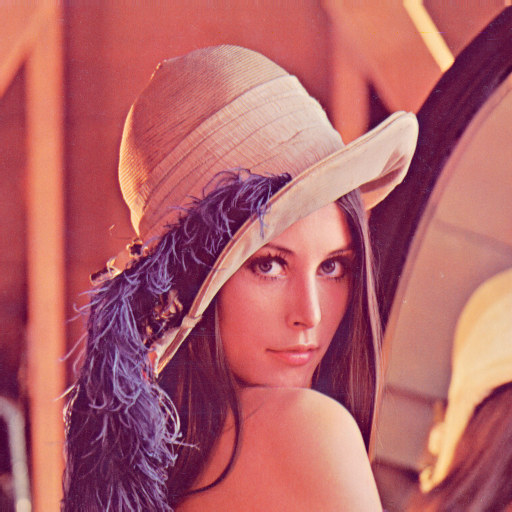

In [ ]:
# 1.
# display image in colab
image_colored = Image.open("/content/drive/MyDrive/Lenna.png")
display ( image_colored )


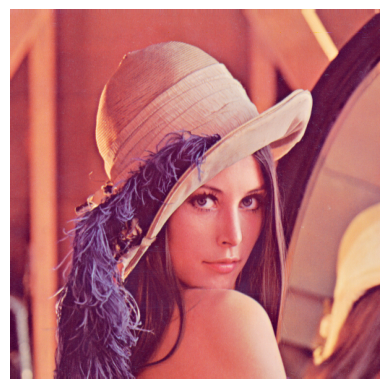

In [ ]:
# Display image using matplotlib
plt.imshow(image_colored)
plt.axis('off')  # Hide axes
plt.show()

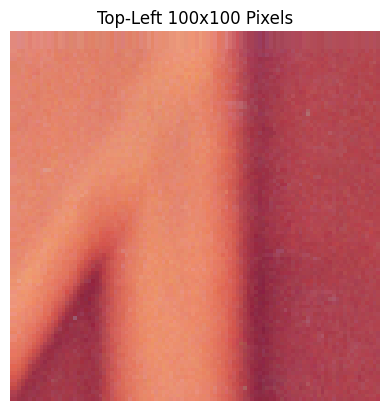

In [ ]:
# 2.
# Convert image to NumPy array
img_array = np.array(image_colored)

# Extract top-left 100x100 region
top_left = img_array[0:100, 0:100]

# Display cropped region
plt.imshow(top_left)
plt.title("Top-Left 100x100 Pixels")
plt.axis("off")
plt.show()

In [ ]:
# 3.
# Separate color channels
R = img_array[:, :, 0]
G = img_array[:, :, 1]
B = img_array[:, :, 2]

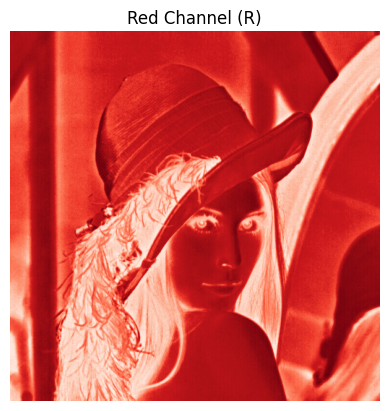

In [ ]:
# Display Red Channel
plt.imshow(R, cmap='Reds')
plt.title("Red Channel (R)")
plt.axis("off")
plt.show()

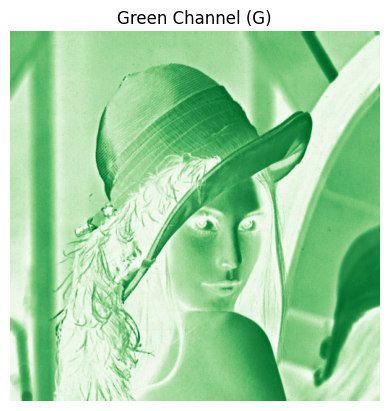

In [ ]:
# Display Green Channel
plt.imshow(G, cmap='Greens')
plt.title("Green Channel (G)")
plt.axis("off")
plt.show()

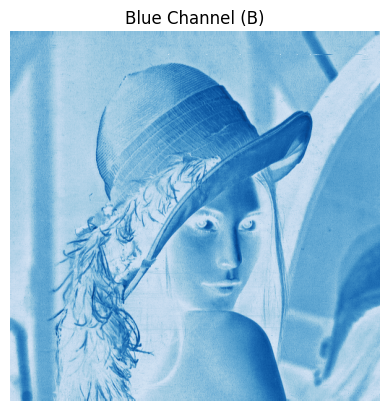

In [ ]:
# Display Blue Channel
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel (B)")
plt.axis("off")
plt.show()

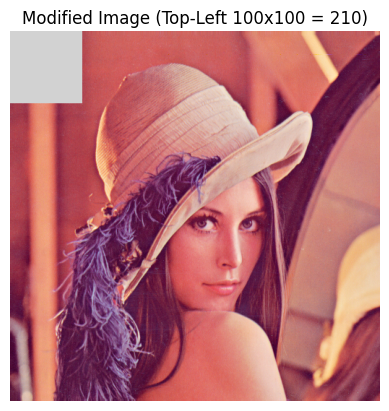

In [ ]:
# Create a copy of original image array
modified_img = img_array.copy()

# Set top-left 100x100 pixels to 210 (light gray)
modified_img[0:100, 0:100] = 210

# Display modified image
plt.imshow(modified_img)
plt.title("Modified Image (Top-Left 100x100 = 210)")
plt.axis("off")
plt.show()

###Exercise - 2:
Complete all the Task.
1. Load and display a grayscale image.
• Load a grayscale image using the Pillow library.
• Display the grayscale image using matplotlib.
2. Extract and display the middle section of the image (150 pixels).
• Extract a 150 pixel section from the center of the image using NumPy array slicing.
• Display this cropped image using matplotlib.
3. Apply a simple threshold to the image (e.g., set all pixel values below 100 to 0).
• Apply a threshold to the grayscale image: set all pixel values below 100 to 0, and all values
above 100 to 255 (creating a binary image).
• Display the resulting binary image.
4. Rotate the image 90 degrees clockwise and display the result.
• Rotate the image by 90 degrees clockwise using the Pillow rotate method or by manipulating
the image array.
• Display the rotated image using matplotlib.
5. Convert the grayscale image to an RGB image.
• Convert the grayscale image into an RGB image where the grayscale values are replicated
across all three channels (R, G, and B).
• Display the converted RGB image using matplotlib.

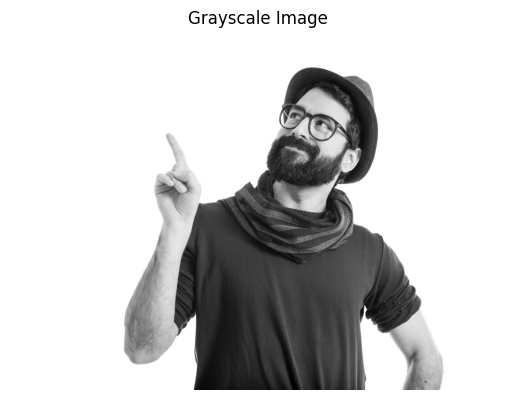

In [ ]:
# 1.
# Load image from Google Drive and convert to grayscale
img = Image.open("/content/drive/MyDrive/Man.jpg").convert("L")

# Convert to NumPy array
img_array = np.array(img)

# Display grayscale image
plt.imshow(img_array, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()

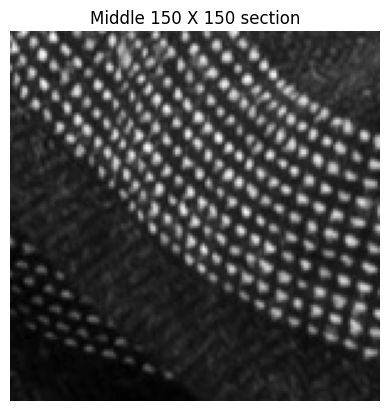

In [ ]:
# 2.
# Get the dimensions of the image
height, width = img_array.shape

# Find the center of the image
center_y, center_x = height // 2, width // 2

# Extract 150 section pixel
middle_section = img_array[center_y-75: center_y+75, center_x-75: center_x+75]

# Display cropped
plt.imshow(middle_section, cmap='gray')
plt.title("Middle 150 X 150 section")
plt.axis("off")
plt.show()

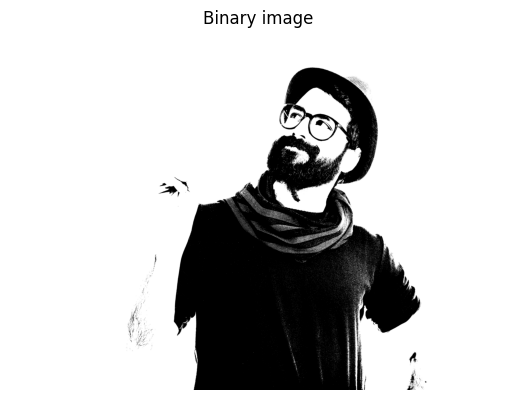

In [ ]:
# 3.
# Set the threshold as Pixel < 100 → 0, Pixel ≥ 100 → 255
binary_image = np.where(img_array < 100, 0, 255)

# Display binary image
plt.imshow(binary_image, cmap='gray')
plt.title("Binary image")
plt.axis("off")
plt.show()


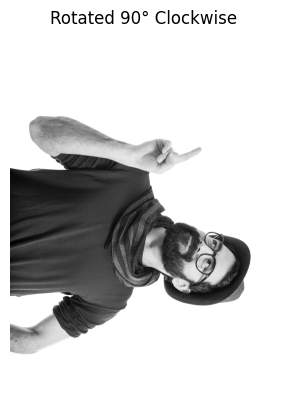

In [ ]:
# 4.
# Rotate the image 90 degrees
rotated_img = np.rot90(img_array, k=-1)

# Display rotated image
plt.imshow(rotated_img, cmap='gray')
plt.title("Rotated 90° Clockwise")
plt.axis("off")
plt.show()

Grayscale Shape: (4330, 6000)
RGB Shape: (4330, 6000, 3)


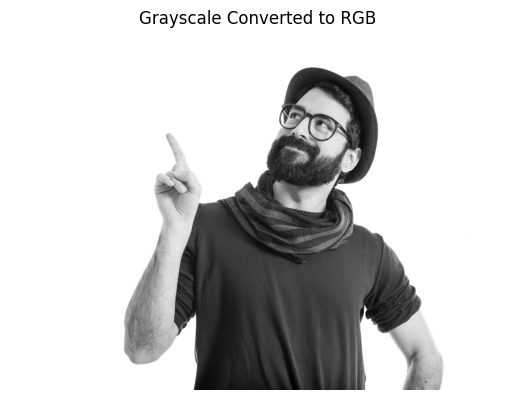

In [ ]:
# 5.
# Original shape of grayscale image
print("Grayscale Shape:", img_array.shape)

# Stack grayscale channel into 3 channels
rgb_image = np.stack((img_array, img_array, img_array), axis=-1)

print("RGB Shape:", rgb_image.shape)

# Display RGB image
plt.imshow(rgb_image)
plt.title("Grayscale Converted to RGB")
plt.axis("off")
plt.show()

###3 Image Compression and Decompression using PCA.
In this exercise, build a PCA from scratch using explained variance method for image compression task.
You are expected to compute the necessary matrices from the scratch. Dataset: Use image of your
choice.
1. Load and Prepare Data:
• Fetch an image of you choice.{If colour convert to grayscale}
• Center the dataset - Standaridze the Data.
• Calculate the covaraince matrix of the Standaridze data.
2. Eigen Decomposition and Identifying Principal Components:
• Compute Eigen Values and Eigen Vectors.
• Sort the eigenvalues in descending order and choose the top k eigenvectors corresponding to
the highest eigenvalues.
• Identify the Principal Components with the help of cumulative Sum plot.
3. Reconstruction and Experiment:

• Reconstruction: Transform the original data by multiplying it with the selected eigenvec-
tors(PCs) to obtain a lower-dimensional representation.

• Experiments: Pick Four different combination of principal components with various ex-
plained variance value and compare the result.

• Display the Results and Evaluate.

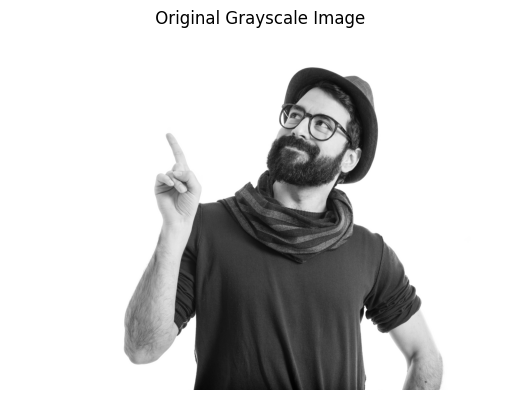

In [ ]:
# 1.
# Load image from Google Drive and convert to grayscale
img = Image.open("/content/drive/MyDrive/Man.jpg").convert("L")

# Convert to NumPy array
img_array = np.array(img)

# Getting height and width
height, width = img_array.shape

# Reshape the image into a 2D array where each rowrepresents a row of pixels
data = img_array . reshape ( height , width )

# Display grayscale image
plt.imshow(img_array, cmap='gray')
plt.title(" Original Grayscale Image")
plt.axis("off")
plt.show()

In [ ]:
# Compute mean of each column
mean = np.mean(data, axis=0)

# Center the data
centered_data = data - mean

In [ ]:
# Compute covariance matrix
cov_matrix = np.cov ( centered_data , rowvar = False )

print("Covariance Matrix Shape:", cov_matrix.shape)

Covariance Matrix Shape: (6000, 6000)


In [ ]:
# 2.
# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# Sort eigenvalues in descending order
sorted_indices = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[sorted_indices]
eigenvectors = eigenvectors[:, sorted_indices]

/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


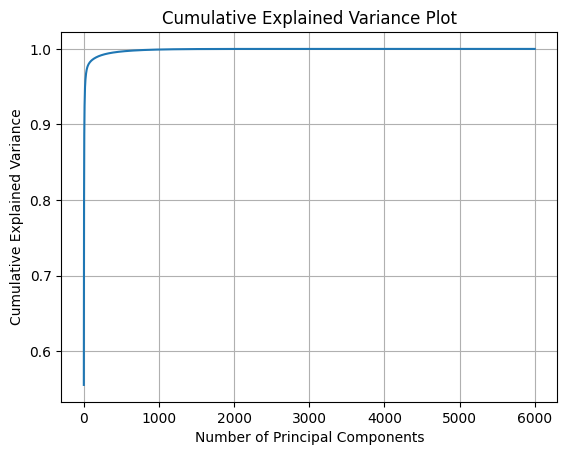

In [ ]:
explained_variance = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(explained_variance)

# Plot cumulative explained variance
plt.plot(cumulative_variance)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance Plot")
plt.grid()
plt.show()

In [ ]:
# 3.
def reconstruct_image(X_centered, eigenvectors, k, mean):

    # Select top k eigenvectors
    components = eigenvectors[:, :k]

    # Project data
    compressed_data = np.dot(X_centered, components)
    # Reconstruct
    X_reconstructed = np.dot(compressed_data, components.T) + mean

    return X_reconstructed

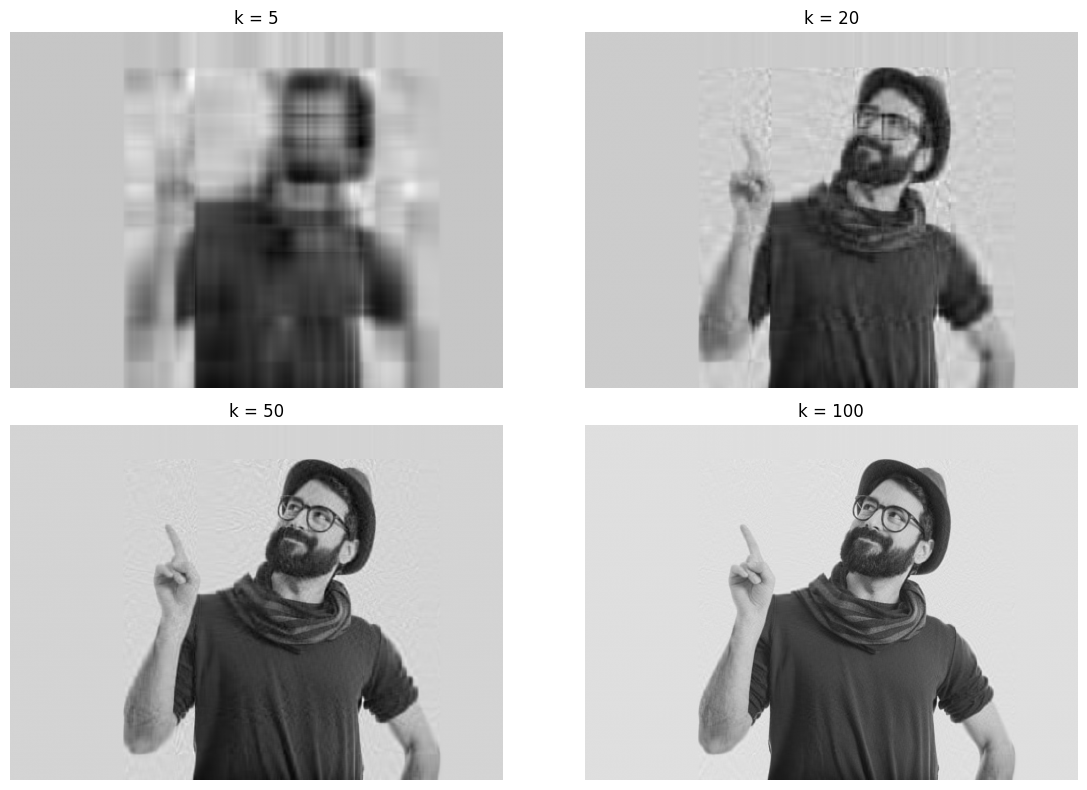

In [ ]:
k_values = [5, 20, 50, 100]

plt.figure(figsize=(12,8))

for i, k in enumerate(k_values):

    reconstructed = reconstruct_image(centered_data, eigenvectors, k, mean)

    plt.subplot(2,2,i+1)
    plt.imshow(reconstructed.real, cmap='gray')
    plt.title(f"k = {k}")
    plt.axis("off")

plt.tight_layout()
plt.show()